# 13. Culture Threshold And Concordance Plots (Python)

Minimal plotting notebook for README-linked outputs:
- `fig_13_03_culture_abundance_density`
- `fig_13_04_culture_adjusted_concordance`


In [1]:
from pathlib import Path
import sys

import numpy as np
import pandas as pd
from IPython.display import SVG, display

ROOT = Path.cwd()
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

import workflow_core as wc

context, base_data, base, advanced = wc.bootstrap_notebook()

## Load Inputs


In [2]:
import math

import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid", context="talk")
plt.rcParams["svg.fonttype"] = "none"
plt.rcParams["pdf.fonttype"] = 42

mixed_concordance = pd.read_csv(
    wc.table_path(context, 34, "culture_mixed_concordance"), sep="\t"
)
descriptive_concordance = pd.read_csv(
    wc.table_path(context, 6, "culture_concordance"), sep="\t"
)
qc = base_data["qc"].copy()
species_bac = base_data["species_bac"]
_, culture_plot_df = base.make_culture_abundance_table(qc, species_bac)
abundance_plot_df = culture_plot_df.copy()
abundance_plot_df["culture_status"] = np.where(
    abundance_plot_df["culture_positive"], "Culture positive", "Culture negative"
)
abundance_plot_df["log10_rel_abundance"] = np.log10(
    abundance_plot_df["relative_abundance"] + 1e-6
)

## Plot Helpers


In [3]:
def save_svg_and_jpg(fig: plt.Figure, output_path: Path) -> None:
    output_path.parent.mkdir(parents=True, exist_ok=True)
    fig.savefig(output_path, bbox_inches="tight")
    fig.savefig(output_path.with_suffix(".jpg"), bbox_inches="tight", dpi=300)


def axes_grid(
    n_panels: int,
    ncols: int = 3,
    panel_width: float = 2.0,
    panel_height: float = 3.0,
):
    ncols = max(1, min(ncols, n_panels if n_panels > 0 else 1))
    nrows = max(1, math.ceil(n_panels / ncols))
    fig, axes = plt.subplots(
        nrows,
        ncols,
        figsize=(panel_width * ncols, panel_height * nrows),
        squeeze=False,
    )
    return fig, [ax for row in axes for ax in row]


def plot_abundance_boxplot(
    abundance_df: pd.DataFrame,
    summary_df: pd.DataFrame,
    output_path: Path,
) -> None:
    q_lookup = summary_df.set_index("label")["qvalue"].to_dict()
    label_order = (
        abundance_df[["group", "label"]]
        .drop_duplicates()
        .sort_values("group")["label"]
        .tolist()
    )
    status_order = ["Culture negative", "Culture positive"]
    palette = {
        "Culture negative": "#4c78a8",
        "Culture positive": "#d65f5f",
    }

    fig, axes = axes_grid(len(label_order), ncols=3, panel_width=2.0, panel_height=3.0)
    for idx, label in enumerate(label_order):
        ax = axes[idx]
        sub = abundance_df.loc[abundance_df["label"] == label].copy()
        sns.boxplot(
            data=sub,
            x="culture_status",
            y="log10_rel_abundance",
            order=status_order,
            palette=palette,
            width=0.62,
            fliersize=3.0,
            linewidth=1.0,
            ax=ax,
        )
        qvalue = q_lookup.get(label, np.nan)
        ax.set_title(f"{label} U-test q={qvalue:.3f}", fontsize=10)
        ax.set_xlabel("")
        ax.set_ylabel("log10(rel. abundance + 1e-6)", fontsize=9)
        ax.set_xticklabels(
            [tick.get_text().split()[-1].capitalize() for tick in ax.get_xticklabels()],
            rotation=20,
            ha="right",
            fontsize=8,
        )
        ax.set_yticklabels([tick.get_text() for tick in ax.get_yticklabels()], fontsize=8)

    for ax in axes[len(label_order):]:
        ax.set_axis_off()

    fig.suptitle("Metagenomic abundance by culture status (boxplots)", y=0.995, fontsize=13)
    fig.tight_layout(rect=(0, 0, 1, 0.98))
    save_svg_and_jpg(fig, output_path)
    plt.close(fig)


def plot_adjusted_concordance(
    concordance_df: pd.DataFrame,
    output_path: Path,
) -> None:
    plot_df = concordance_df.loc[
        concordance_df["status"].isin(["ok", "ok_singular"])
    ].copy()
    plot_df["significant"] = plot_df["qvalue"].fillna(1.0) <= 0.1
    plot_df["fit_quality"] = np.where(
        plot_df["status"] == "ok_singular",
        "Singular fit",
        "Regular fit",
    )
    plot_df = plot_df.sort_values("estimate").reset_index(drop=True)

    fig, ax = plt.subplots(figsize=(9, 0.55 * len(plot_df)))
    ax.axvline(0, color="#808080", linestyle="--", linewidth=0.9)
    color_map = {True: "#b22222", False: "#3b6a8f"}
    marker_map = {"Regular fit": "o", "Singular fit": "^"}

    y_values = np.arange(len(plot_df))
    for idx, row in plot_df.iterrows():
        x = float(row["estimate"])
        low = float(row["conf.low"])
        high = float(row["conf.high"])
        ax.hlines(
            y=idx,
            xmin=low,
            xmax=high,
            color=color_map[row["significant"]],
            linewidth=2,
        )
        ax.scatter(
            x,
            idx,
            color=color_map[row["significant"]],
            marker=marker_map[row["fit_quality"]],
            s=80,
            edgecolor="black",
            linewidth=0.5,
            zorder=3,
        )
        qvalue = row.get("qvalue", np.nan)
        q_text = f"q={qvalue:.3g}" if pd.notna(qvalue) else "q=NA"
        ax.text(high + 0.01, idx, q_text, va="center", fontsize=9)

    ax.set_yticks(y_values)
    ax.set_yticklabels(plot_df["label"])
    ax.set_xlabel("Adjusted effect (normal-score abundance)")
    ax.set_ylabel("")
    ax.set_title("Adjusted culture-metagenomics concordance")
    fig.tight_layout()
    save_svg_and_jpg(fig, output_path)
    plt.close(fig)

## Render Figure 13 Panels


/tmp/ipykernel_2755018/2702729247.py:46: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
/tmp/ipykernel_2755018/2702729247.py:61: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(
/tmp/ipykernel_2755018/2702729247.py:67: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_yticklabels([tick.get_text() for tick in ax.get_yticklabels()], fontsize=8)
/tmp/ipykernel_2755018/2702729247.py:46: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
/tmp/ipykernel_2755018/2702729247.py:61: UserWarning: set_ticklabels() should

/tmp/ipykernel_2755018/2702729247.py:61: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(
/tmp/ipykernel_2755018/2702729247.py:67: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_yticklabels([tick.get_text() for tick in ax.get_yticklabels()], fontsize=8)
/tmp/ipykernel_2755018/2702729247.py:46: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
/tmp/ipykernel_2755018/2702729247.py:61: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(
/tmp/ipykernel_2755018/2702729247.py:67: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e.

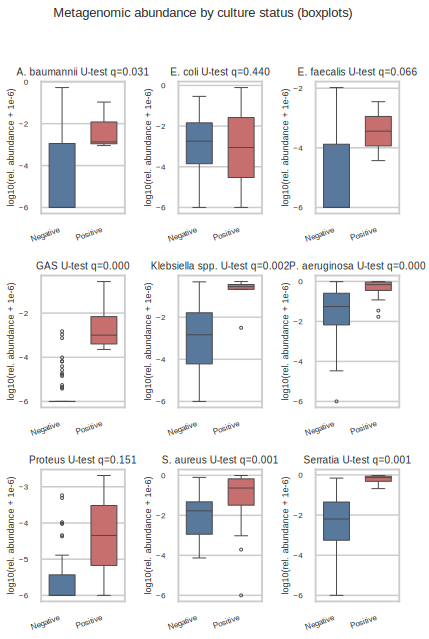

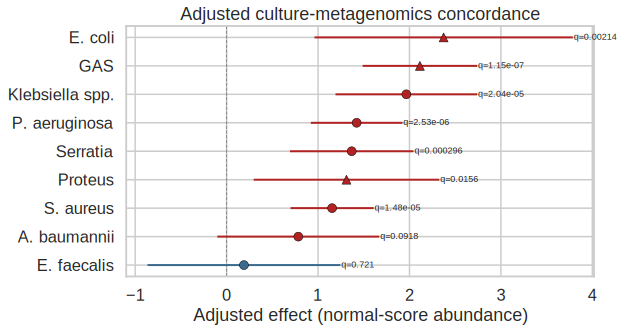

In [4]:
fig_abundance = wc.figure_path(context, 16, "culture_abundance_density")
plot_abundance_boxplot(abundance_plot_df, descriptive_concordance, fig_abundance)

fig_adjusted = wc.figure_path(context, 17, "culture_adjusted_concordance")
plot_adjusted_concordance(mixed_concordance, fig_adjusted)

display(SVG(filename=str(fig_abundance)))
display(SVG(filename=str(fig_adjusted)))